# Project 5: Ensemble Machine Learning – Wine Dataset

- Author: Kim Hummel
- Date: 2026-07
- Dataset: Red Wine Dataset from UCI Machine Learning Repository
- Target: Quality (integer score from 0 to 10, rated by wine tasters)

In this project we will follow the outline provided by Denise Case. We’ll predict quality, it's 0 to 10 rating from wine tasters, using all of the other features provided in the dataset: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates and alcohol

Dataset can be found here: https://archive.ics.uci.edu/dataset/186/wine+quality

Project 5 Direction Here: https://nwmissouri.instructure.com/courses/79085/pages/project-5-instructions-ensemble-ml-spiral-wine?module_item_id=2867110 


# Section 0: Imports 

In [43]:
# ------------------------------------------------
# Imports once at the top, organized
# ------------------------------------------------

# === 1a. ALL IMPORTS

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05", level="DEBUG")
log_header(LOG, "M05")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-08-02 15:48:45 | INFO | M05 | === RUN START ===
2026-08-02 15:48:45 | INFO | M05 | project=M05
2026-08-02 15:48:45 | INFO | M05 | repo_dir=ml-05-ensembles
2026-08-02 15:48:45 | INFO | M05 | python=3.14.3
2026-08-02 15:48:45 | INFO | M05 | os=Windows 11
2026-08-02 15:48:45 | INFO | M05 | shell=powershell
2026-08-02 15:48:45 | INFO | M05 | cwd=notebooks\project05
2026-08-02 15:48:45 | INFO | M05 | github_actions=False
2026-08-02 15:48:45 | INFO | M05 | Confirming installation:
2026-08-02 15:48:45 | INFO | M05 |   python:       3.14.3
2026-08-02 15:48:45 | INFO | M05 |   pandas:       3.0.5
2026-08-02 15:48:45 | INFO | M05 |   numpy:        2.5.1
2026-08-02 15:48:45 | INFO | M05 |   scikit-learn: 1.9.0
2026-08-02 15:48:45 | INFO | M05 |   seaborn:      0.13.2
2026-08-02 15:48:45 | INFO | M05 |   matplotlib:   3.11.1


# Section 1. Load and Inspect the Data

In [44]:
# Load the dataset (download from UCI and save in the same folder)
df = pd.read_csv("winequality-red.csv")

# Display structure and first few rows
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   ph                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   float64
dtypes: float64(12)
memory usage: 150.0 KB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


The dataset includes 11 physicochemical input variables (features):
---------------------------------------------------------------
- fixed acidity          - mostly tartaric acid
- volatile acidity       - mostly acetic acid (vinegar)
- citric acid            - can add freshness and flavor
- residual sugar         - remaining sugar after fermentation
- chlorides              - salt content
- free sulfur dioxide    - protects wine from microbes
- total sulfur dioxide   - sum of free and bound forms
- density                - related to sugar content
- pH                     - acidity level (lower = more acidic)
- sulphates              - antioxidant and microbial stabilizer
- alcohol                - % alcohol by volume

The target variable is:
- quality (integer score from 0 to 10, rated by wine tasters)

We will simplify this target into three categories:
  - We will keep its original 0 - 10 score
  - low (3–4), medium (5–6), high (7–8) to make classification feasible.
  - we will also make the classification numeric (we want both for clarity)

# Section 2. Prepare the Data

For this project, it means creating two new columns. 

In [45]:
# This function will be used to create the quality_label column
def quality_to_label(q):
    if q <= 4:
        return "low"
    elif q <= 6:
        return "medium"
    else:
        return "high"


# Call the apply() method on the quality column to create the new quality_label column
df["quality_label"] = df["quality"].apply(quality_to_label)


# Then, create a numeric column for modeling: 0 = low, 1 = medium, 2 = high
def quality_to_number(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2


df["quality_numeric"] = df["quality"].apply(quality_to_number)

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,quality_label,quality_numeric
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,medium,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0,medium,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0,medium,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0,medium,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,medium,1


In [46]:
# Target and Feature columns for later graphing

# the target:
TARGET_COL: Final[str] = "quality_numeric"

# The features:
FEATURE_COLS: Final[list[str]] = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "ph",
    "sulfates",
    "alcohol",
]

# Section 3. Feature Selection and Justification

In [47]:
# Define input features (X) and target (y)
# Features: all columns except 'quality' and 'quality_label' and 'quality_numberic' - drop these from the input array
# Target: quality_label (the new column we just created)

X = df.drop(columns=["quality", "quality_label", "quality_numeric"])  # Features
y = df["quality_numeric"]  # Target

# Section 4. Split the Data into Train and Test

In [48]:
# Train/test split (stratify to preserve class balance)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-08-02 15:48:46 | INFO | M05 | Train instances: 1279
2026-08-02 15:48:46 | INFO | M05 | Test instances: 320


# Section 5.  Evaluate Model Performance

I chose four models to evaluate the data with: Random Forest (200, max depth=10), AdaBoost (100), Voting(DT + SVM + NN), and Bagging (DT, 100). 

In [49]:
# Helper function to train and evaluate models
def evaluate_model(name, model, X_train, y_train, X_test, y_test, results):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")

    print(f"\n{name} Results")
    print("Confusion Matrix (Test):")
    print(confusion_matrix(y_test, y_test_pred))
    print(f"Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
    print(f"Train F1 Score: {train_f1:.4f}, Test F1 Score: {test_f1:.4f}")

    results.append(
        {
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Train F1": train_f1,
            "Test F1": test_f1,
        }
    )


results = []

# 2. Random Forest (200, max depth=10)

rain_forest_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42
)

evaluate_model(
    "Random Forest (200, max_depth=10)",
    rain_forest_model,
    X_train,
    y_train,
    X_test,
    y_test,
    results,
)


Random Forest (200, max_depth=10) Results
Confusion Matrix (Test):
[[  0  13   0]
 [  0 255   9]
 [  0  16  27]]
Train Accuracy: 0.9734, Test Accuracy: 0.8812
Train F1 Score: 0.9716, Test F1 Score: 0.8596


In [50]:
# 3. AdaBoost
evaluate_model(
    "AdaBoost (100)",
    AdaBoostClassifier(n_estimators=100, random_state=42),
    X_train,
    y_train,
    X_test,
    y_test,
    results,
)


AdaBoost (100) Results
Confusion Matrix (Test):
[[  1  12   0]
 [  5 245  14]
 [  0  27  16]]
Train Accuracy: 0.8342, Test Accuracy: 0.8187
Train F1 Score: 0.8133, Test F1 Score: 0.8009


In [51]:
# 6. Voting Classifier (DT, SVM, NN)
voting1 = VotingClassifier(
    estimators=[
        ("DT", DecisionTreeClassifier()),
        ("SVM", SVC(probability=True)),
        ("NN", MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000)),
    ],
    voting="soft",
)
evaluate_model(
    "Voting (DT + SVM + NN)", voting1, X_train, y_train, X_test, y_test, results
)

c:\Repos\Applied_Machine_Learning\ml-05-ensembles\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Voting (DT + SVM + NN) Results
Confusion Matrix (Test):
[[  0  12   1]
 [  0 248  16]
 [  0  16  27]]
Train Accuracy: 0.9265, Test Accuracy: 0.8594
Train F1 Score: 0.9080, Test F1 Score: 0.8412


In [52]:
# 8. Bagging
evaluate_model(
    "Bagging (DT, 100)",
    BaggingClassifier(
        estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42
    ),
    X_train,
    y_train,
    X_test,
    y_test,
    results,
)


Bagging (DT, 100) Results
Confusion Matrix (Test):
[[  0  13   0]
 [  0 253  11]
 [  0  12  31]]
Train Accuracy: 1.0000, Test Accuracy: 0.8875
Train F1 Score: 1.0000, Test F1 Score: 0.8682


# Section 6: Compare Results

Create a table to easily compare the results of the four models. 

In [53]:
# Create a table of results
results_df = pd.DataFrame(results)

results_df["Decrease In Accuracy"] = (
    results_df["Train Accuracy"] - results_df["Test Accuracy"]
)

results_df["Decrease In F1"] = results_df["Train F1"] - results_df["Test F1"]

print("\nSummary of All Models:")
display(results_df)


Summary of All Models:


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Decrease In Accuracy,Decrease In F1
0,"Random Forest (200, max_depth=10)",0.973417,0.881250,0.971621,0.859643,0.092167,0.111978
1,AdaBoost (100),0.834246,0.818750,0.813349,0.800863,0.015496,0.012486
2,Voting (DT + SVM + NN),0.926505,0.859375,0.908012,0.841183,0.067130,0.066829
3,"Bagging (DT, 100)",1.000000,0.887500,1.000000,0.868218,0.112500,0.131782


## Sections 5 & 6 Reflection 

I chose these four models because I wanted to compare the different type of models. I chose the Random Forest, but since we did a random forest in phase 4 of the project, I decided to go with the one with different limitations; 200, max depth = 10. I chose Ada Boost to see a boosting example. I chose bagging to see a bagging example. Lastly I chose the voting example with the decision tree, SVM, and neural network ( DT + SVM + NN) since these were regression models we used in the previous weeks, so I could see how they all worked together. 

After running all of the models we created a table that made it easy to compare all of the results. I added two columns that compared the training and testing data for accuracy and F1. I did this by subtracting the test values from the train values. After I saw that all of the training data was higher than the testing data I changed the titles of my created columns to "Decrease In" to better describe what the numbers in the newly created columns meant. 

# Section 7: Conclusion and Insights

Bagging had the highest test accuracy and test F1. It is worth noting that it had the biggest decrease in both accuracy and F1 between the training and testing data, which would be expected as the the training accuracy and F1 scored a 1.0. The bagging model most likely worked well with this data because you would expect there to be a high variance between quality scores as they are based on personal opinion, not quantitative data. 


Since it has the highest testing data, it would be an appropriate choice to graph the features in order of importance. However, I don't know how to do that with a bagging model, but do know how to do it with a random forest. Since the random forest has the second highest test accuracy and F1 scores, I decided it would be acceptable to graph it's features. 

2026-08-02 15:48:51 | INFO | M05 | Bagging feature importances (high to low):
2026-08-02 15:48:51 | INFO | M05 |   alcohol              0.162
2026-08-02 15:48:51 | INFO | M05 |   volatile_acidity     0.123
2026-08-02 15:48:51 | INFO | M05 |   sulfates             0.110
2026-08-02 15:48:51 | INFO | M05 |   citric_acid          0.084
2026-08-02 15:48:51 | INFO | M05 |   total_sulfur_dioxide 0.081
2026-08-02 15:48:51 | INFO | M05 |   density              0.081
2026-08-02 15:48:51 | INFO | M05 |   fixed_acidity        0.079
2026-08-02 15:48:51 | INFO | M05 |   chlorides            0.078
2026-08-02 15:48:51 | INFO | M05 |   residual_sugar       0.076
2026-08-02 15:48:51 | INFO | M05 |   ph                   0.066
2026-08-02 15:48:51 | INFO | M05 |   free_sulfur_dioxide  0.060


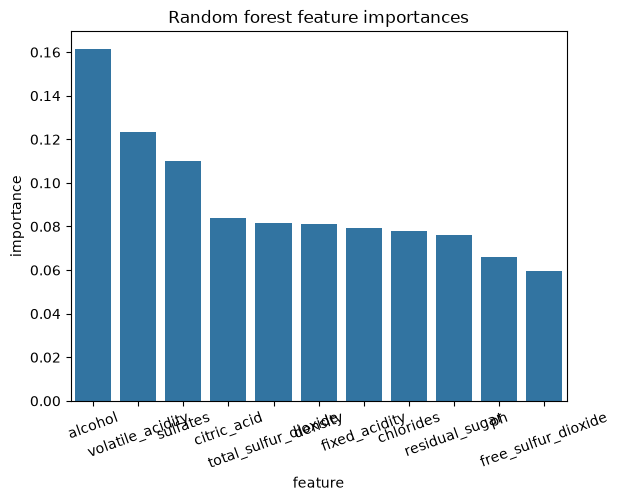

In [54]:
"""Chart the Bagging (DT, 100) feature importances.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue, not proof of causation.

Interpret them with the same care as any other finding.
"""
# get the feature importances
# from the fitted random forest model
importances: np.ndarray = rain_forest_model.feature_importances_

# argsort returns indices that would sort the array ascending
# [::-1] reverses it so the most important feature comes first
order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Bagging feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS[i]:20s} {importances[i]:.3f}")

# start a new figure
plt.figure()

# create x and y values for the bar chart, ordered from high to low importance
x_values = [FEATURE_COLS[i] for i in order]
y_values = importances[order]

# create a bar chart of the importances, ordered from high to low
sns.barplot(x=x_values, y=y_values)

# label the axes and title
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances")

# slight rotation for readability (optional)
plt.xticks(rotation=20)

# show the plot
plt.show()

Alcohol, volatile acidity, and sulfates are the three highest features. 

### Next Steps 

Next steps would be to learn how to graph features in order of importance on other models besides random forests. This way it could be done on all four models and they could be compared. 

Additionally, we could look into the model types more specifically to better understand why the bagging model worked the best. Specifically with the bagging model, how was it able to attain training scores of 1.0. 

We could use this model on the white wine list and see if it maintained its accuracy for white wine as well. 